#### Follow tutorial
https://towardsdatascience.com/advanced-missing-data-imputation-methods-with-sklearn-d9875cbcc6eb

In [34]:
import pandas as pd
import numpy as np
from io import StringIO

In [292]:
materialData = pd.read_excel('ASHRAE_Original.xlsx')
materialData

,No.,material category,description,density (lb/ft3),"conductivity, k/λ (Btu in/(ft2 h °F))","resistance, R (h ft2 °F/Btu)",specific heat (Btu/(lb °F)),note,reference
0,1,"Insulating material: Blanket and batt c, d",Glass-fiber batts,NaN,NaN,NaN,0.2,[a],Kumaran (2002)
1,2,"Insulating material: Blanket and batt c, d",Glass-fiber batts,0.47 - 0.51,0.32 - 0.33,NaN,NaN,[a],Four manufacturers (2011)
2,3,"Insulating material: Blanket and batt c, d",Glass-fiber batts,0.61 - 0.75,0.28 - 0.30,NaN,NaN,[a],Four manufacturers (2011)
3,4,"Insulating material: Blanket and batt c, d",Glass-fiber batts,0.79 - 0.85,0.26 - 0.27,NaN,NaN,[a],Four manufacturers (2011)
4,5,"Insulating material: Blanket and batt c, d",Glass-fiber batts,1.4,0.23,NaN,NaN,[a],Four manufacturers (2011)
...,...,...,...,...,...,...,...,...,...
250,251,Woods (12% moisture content) l: Hardwoods,"West coast woods, cedars",22 - 31,0.68 - 0.90,NaN,NaN,[a],Cardenas and Bible (1987)
251,252,Woods (12% moisture content) l: Hardwoods,Eastern white cedar.,23,0.82 - 0.89,NaN,NaN,[a],Kumaran (2002)
252,253,Woods (12% moisture content) l: Hardwoods,California redwood,24 - 28,0.74 - 0.82,NaN,NaN,[a],Cardenas and Bible (1987)
253,254,Woods (12% moisture content) l: Hardwoods,Pine (oven-dried),23,0.64,NaN,0.45,[a],Kumaran (1996)


In [294]:
#MaterialCategory
materialCategory = materialData['material category']
materialDescription = materialData['description']

print(materialCategory.unique())
print(materialDescription.unique())
print(len(materialCategory.unique()))
print(len(materialDescription.unique()))


['Insulating material: Blanket and batt c, d'
 'Insulating material: Board and slabs' 'Insulating material: Loose fill'
 'Insulating material: Spray applied' 'Building Board and Siding: Board'
 'Building Board and Siding: Shingles' 'Building Board and Siding: Siding'
 'Building Membrane' 'Finish Flooring'
 'Metal roofing (See Chapter 33, Table 3)' 'Plastering Materials'
 'Masonry Materials: Masonry units' 'Masonry Materials: Concrete blocks h'
 'Masonry Materials: Concretes'
 'Woods (12% moisture content) l: Hardwoods'
 'Woods (12% moisture content) l: Softwoods']
['Glass-fiber batts' 'Rock and slag wool batts' 'Mineral wool, felted'
 'Cellular glass'
 'Cement fiber slabs, shredded wood with portland cement binder'
 'Cement fiber slabs, shredded wood with portland cement with magnesia oxysulfide binder'
 'Glass fiber board' 'Expanded rubber (rigid)'
 'Extruded polystyrene, smooth skin'
 'Extruded polystyrene, smooth skin aged per CAN/ULC Standard S770-2003.'
 'Extruded polystyrene, smo

In [296]:
#SPLIT Specific Heat Value

#Function to split float, when inside
def heat_split(name):
    if pd.isna(name): # Check for NaN values
        return pd.Series([np.nan, np.nan])
    name = str(name)  # Convert to string if not already
    if ' - ' in name:
        return pd.Series(name.split(' - ', 1))
    else:
        return pd.Series([name, name])

#Specific Heat (Btu/(lb °F))
heat_split = materialData['specific heat (Btu/(lb °F))'].apply(heat_split)

# Name the new columns appropriately, for example 'density_min' and 'density_max'
materialData['heat_min'] = heat_split[0]
materialData['heat_max'] = heat_split[1]

materialData['heat_min'] = pd.to_numeric(materialData['heat_min']) * 4.1868 * 1000
materialData['heat_max'] = pd.to_numeric(materialData['heat_max']) * 4.1868 * 1000
materialData['heat_median'] = (materialData['heat_min'] + materialData['heat_max']) / 2
materialHeat = materialData['heat_median']

#Convert from Specific Heat Capacity  (Btu/(lb °F)) to [J/kg.K]
#1 BTU/Pound °F (BTU/lb∙°F) = 4.1868 Kilojoule/Kilogram K (kJ/kg∙K) AND times 1000 to convert to J/kg∙K

print(len(materialHeat), materialHeat)

255 0       837.36
1          NaN
2          NaN
3          NaN
4          NaN
        ...   
250        NaN
251        NaN
252        NaN
253    1884.06
254    1884.06
Name: heat_median, Length: 255, dtype: float64


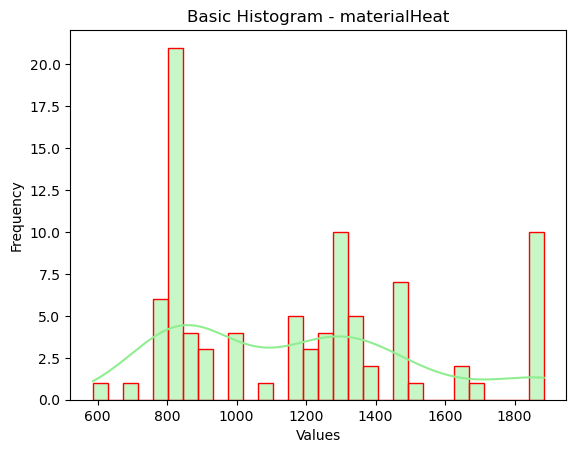

In [298]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate random data for the histogram
data = materialHeat
 
# Plotting a basic histogram
#plt.hist(data, bins=30, color='skyblue', edgecolor='black')
sns.histplot(data, bins=30, kde=True, color='lightgreen', edgecolor='red')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram - materialHeat')
 
# Display the plot
plt.show()

In [300]:
#SPLIT Density

#Function to split float, when inside
def density_split(name):
    if pd.isna(name):  # Check for NaN values
        return pd.Series([np.nan, np.nan])
    name = str(name)  # Convert to string if not already
    if ' - ' in name:
        return pd.Series(name.split(' - ', 1))
    else:
        return pd.Series([name, name])

#Density (lb/ft3) >>>
# Use str.split with expand=True to split the values and create two new columns
#density_split = materialData['density (lb/ft3)'].str.split(' - ', expand=True)
density_split = materialData['density (lb/ft3)'].apply(density_split)

# Name the new columns appropriately, for example 'density_min' and 'density_max'
materialData['density_min'] = density_split[0]
materialData['density_max'] = density_split[1]
# Convert the new columns to numeric
materialData['density_min'] = pd.to_numeric(materialData['density_min']) * 16.0184634
materialData['density_max'] = pd.to_numeric(materialData['density_max']) * 16.0184634
materialData['density_median'] = (materialData['density_min'] + materialData['density_max']) / 2
materialDensity = materialData['density_median']

print(materialDensity)
print(len(materialDensity))


0             NaN
1        7.849047
2       10.892555
3       13.135140
4       22.425849
          ...    
250    424.489280
251    368.424658
252    416.480048
253    368.424658
254    400.461585
Name: density_median, Length: 255, dtype: float64
255


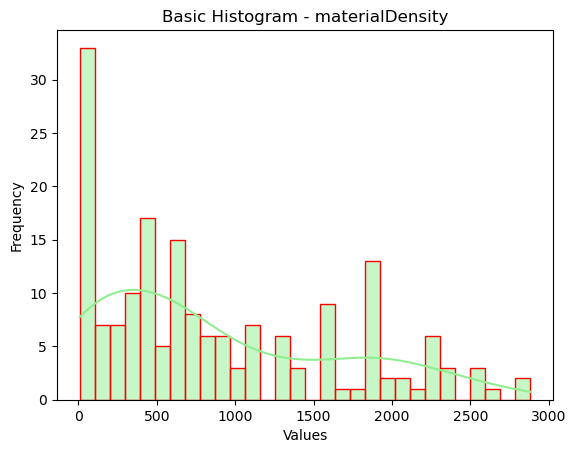

In [302]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate random data for the histogram
data = materialDensity
 
# Plotting a basic histogram
#plt.hist(data, bins=30, color='skyblue', edgecolor='black')
sns.histplot(data, bins=30, kde=True, color='lightgreen', edgecolor='red')

# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram - materialDensity')
 
# Display the plot
plt.show()

In [304]:
#SPLIT Conductivity, 

#Function to split float when - inside
def conductivity_split(name):
    if pd.isna(name):  # Check for NaN values
        return pd.Series([np.nan, np.nan])
    name = str(name)  # Convert to string if not already
    if ' - ' in name:
        return pd.Series(name.split(' - ', 1))
    else:
        return pd.Series([name, name])

conductivity_split = materialData['conductivity, k/λ (Btu in/(ft2 h °F))'].apply(conductivity_split)

#Name the new columns
materialData['conductivity_min'] = conductivity_split[0]
materialData['conductivity_max'] = conductivity_split[1]
# Convert the new columns to numeric
materialData['conductivity_min'] = pd.to_numeric(materialData['conductivity_min']) * 0.144
materialData['conductivity_max'] = pd.to_numeric(materialData['conductivity_max']) * 0.144
materialData['conductivity_median'] = (materialData['conductivity_min'] + materialData['conductivity_max']) / 2    
materialConductivity = materialData['conductivity_median']

print(materialConductivity)
print(len(materialConductivity))
#print(materialCategory, materialDescription, materialDensity, materialConductivity)

#print(materialCategory, materialDescription, materialDensity, materialData[['density (lb/ft3)', 'density_min', 'density_max', 'density_average', 'conductivity_min', 'conductivity_max', 'conductivity_average']])


0          NaN
1      0.04680
2      0.04176
3      0.03816
4      0.03312
        ...   
250    0.11376
251    0.12312
252    0.11232
253    0.09216
254    0.09936
Name: conductivity_median, Length: 255, dtype: float64
255


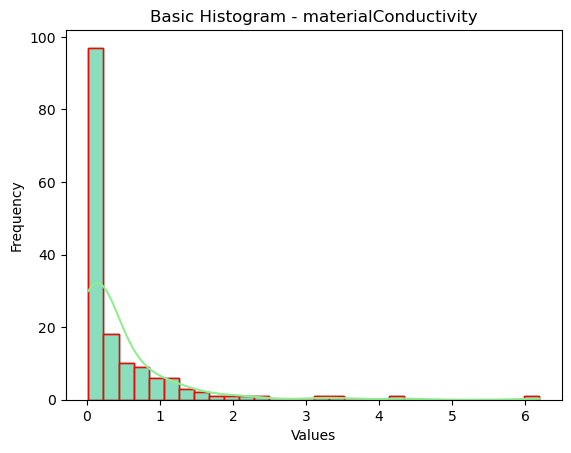

In [306]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate random data for the histogram
data = materialConductivity
 
# Plotting a basic histogram
plt.hist(data, bins=30, color='skyblue', edgecolor='black')
sns.histplot(data, bins=30, kde=True, color='lightgreen', edgecolor='red')


# Adding labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Basic Histogram - materialConductivity')
 
# Display the plot
plt.show()

In [308]:
materialData = pd.DataFrame({
    'materialCategory': materialCategory,  # Use the actual variable
    'materialDescription': materialDescription,  # Use the actual variable
    'materialDensity': materialDensity,  # Use the actual variable
    'materialConductivity': materialConductivity,  # Use the actual variable
    'materialHeatCapacity': materialHeat
})

In [310]:
#materialData.to_excel('ASHRAE_metric.xlsx')

In [312]:
materialData.to_excel("materialData_origib.xlsx", index=False)
print(materialData)

                               materialCategory       materialDescription  \
0    Insulating material: Blanket and batt c, d         Glass-fiber batts   
1    Insulating material: Blanket and batt c, d         Glass-fiber batts   
2    Insulating material: Blanket and batt c, d         Glass-fiber batts   
3    Insulating material: Blanket and batt c, d         Glass-fiber batts   
4    Insulating material: Blanket and batt c, d         Glass-fiber batts   
..                                          ...                       ...   
250   Woods (12% moisture content) l: Hardwoods  West coast woods, cedars   
251   Woods (12% moisture content) l: Hardwoods      Eastern white cedar.   
252   Woods (12% moisture content) l: Hardwoods        California redwood   
253   Woods (12% moisture content) l: Hardwoods         Pine (oven-dried)   
254   Woods (12% moisture content) l: Hardwoods       Spruce (oven-dried)   

     materialDensity  materialConductivity  materialHeatCapacity  
0       

## Correlation Matrix

In [315]:
from scipy import stats
import seaborn as sns

In [317]:
#ASHRAEcorr = materialData.corr()
#round(ASHRAEcorr,2)

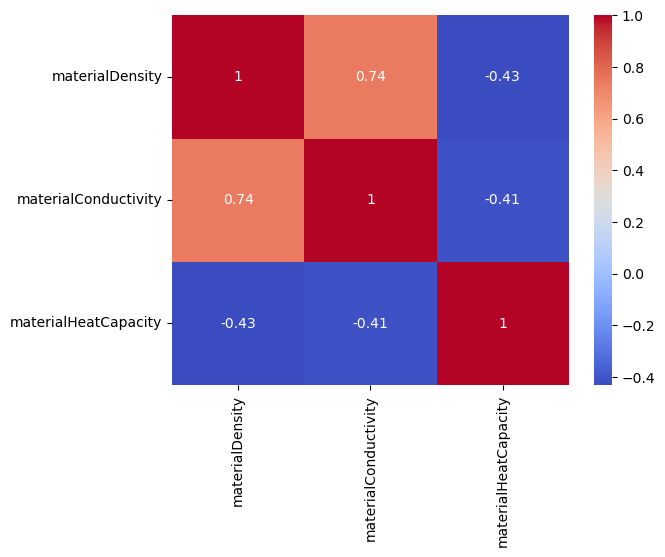

In [319]:
selected_features = materialData.iloc[:, 2:6] 
correlation_matrix = selected_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm');

## Analyse type of missingness

In [322]:
!pip install missingno

In [323]:
import missingno as msno

<Axes: >

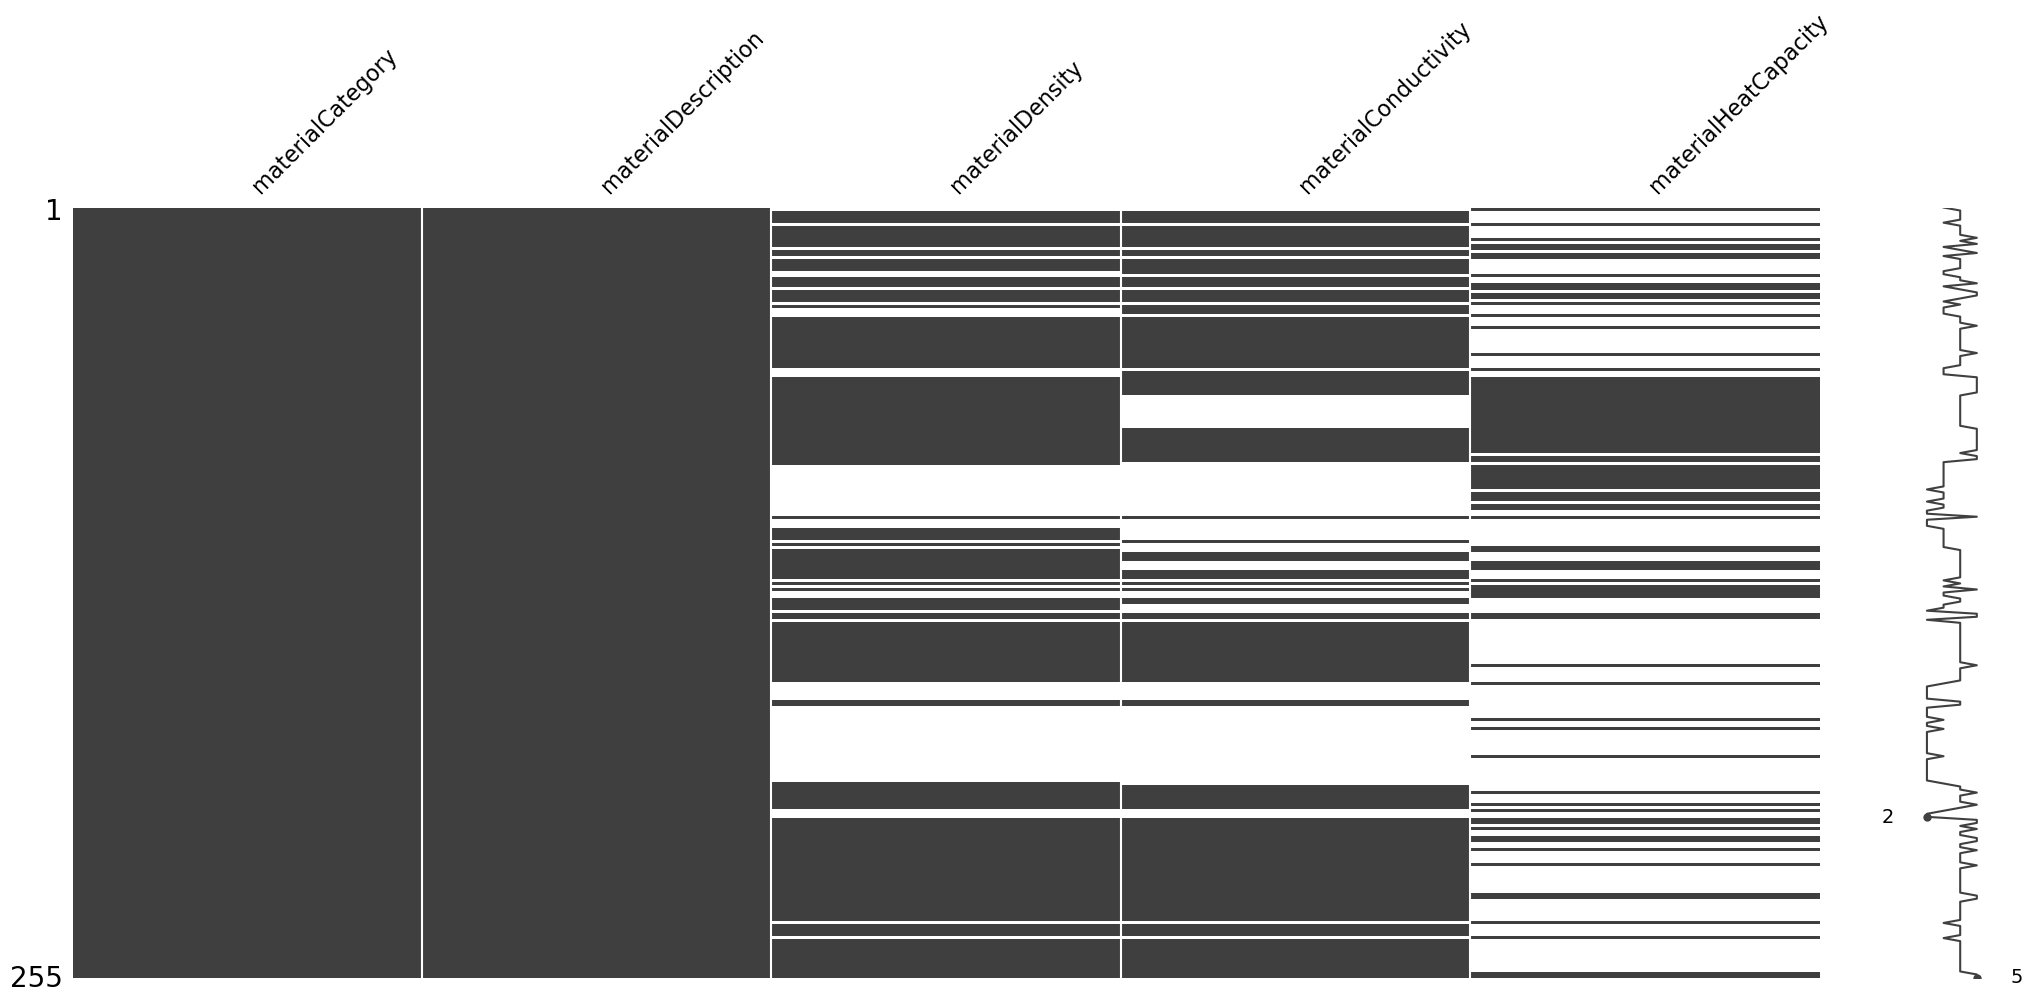

In [324]:
msno.matrix(materialData)
#This matrix shows how nulls are scattered across the dataset

<Axes: >

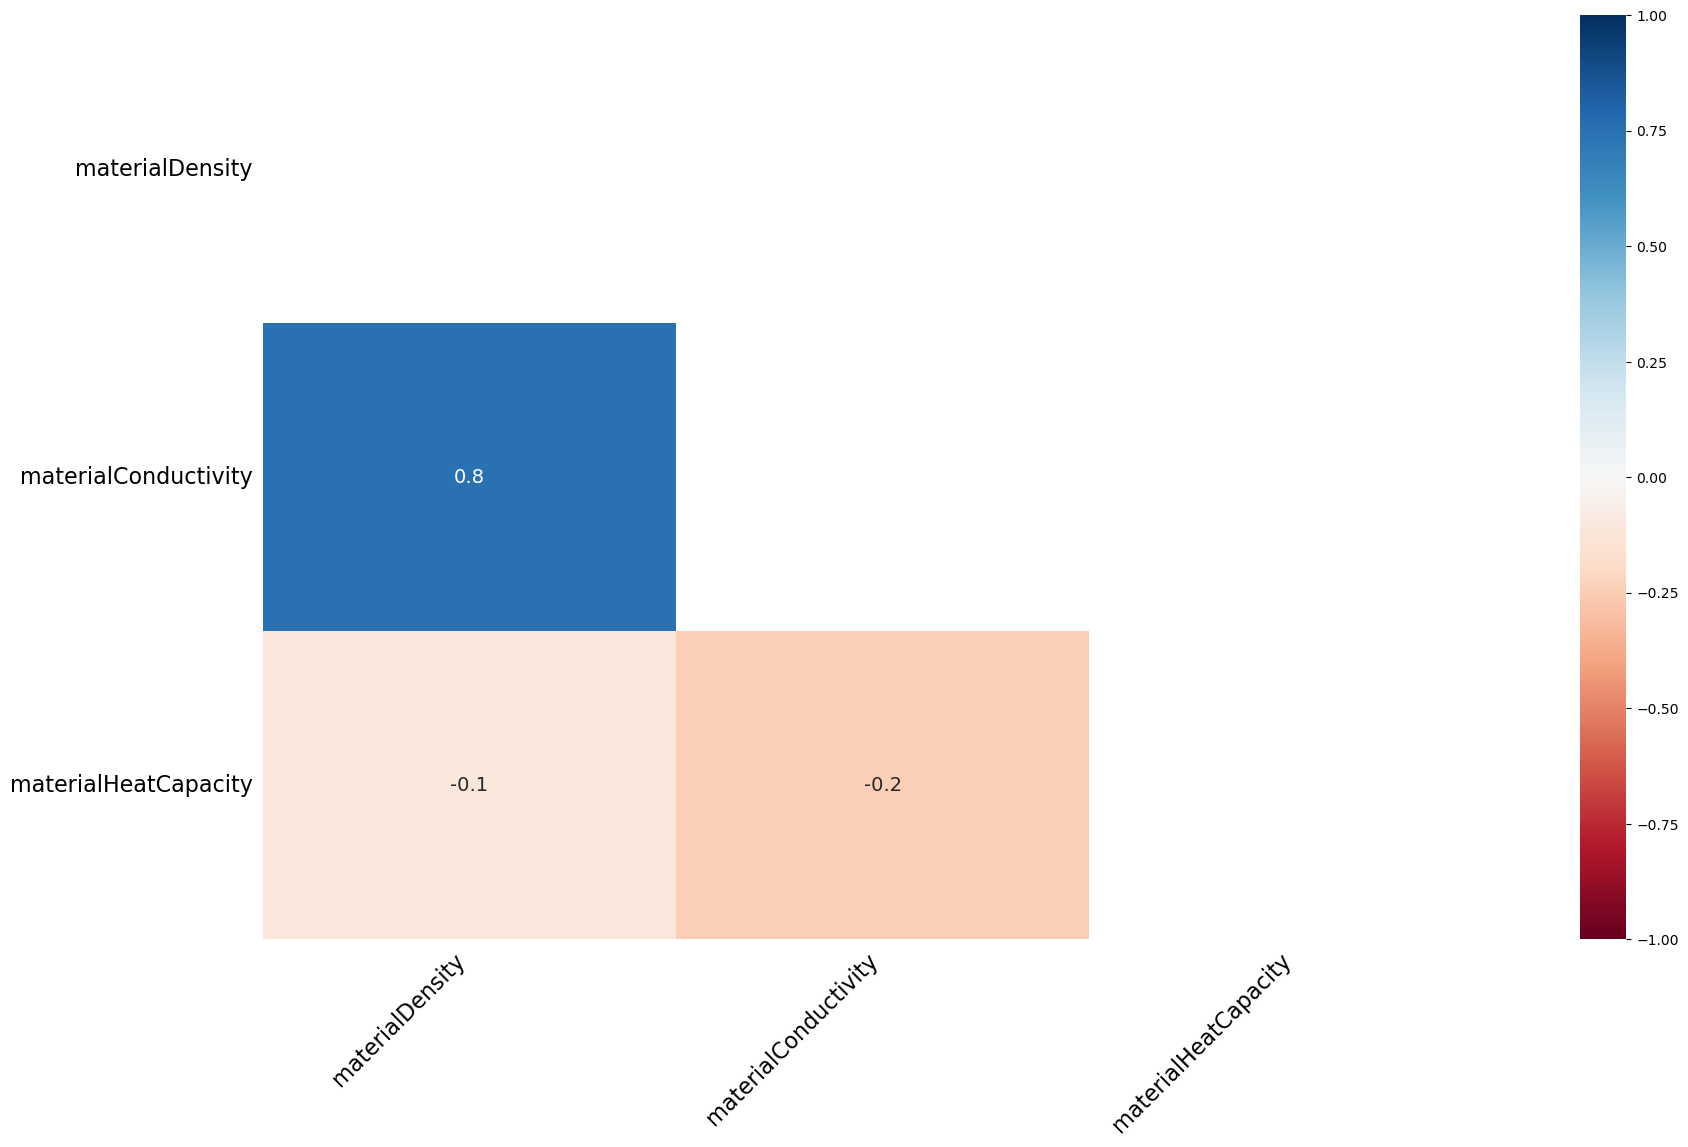

In [325]:
#Is there a relationship between the missingness inside the data?
msno.heatmap(materialData)

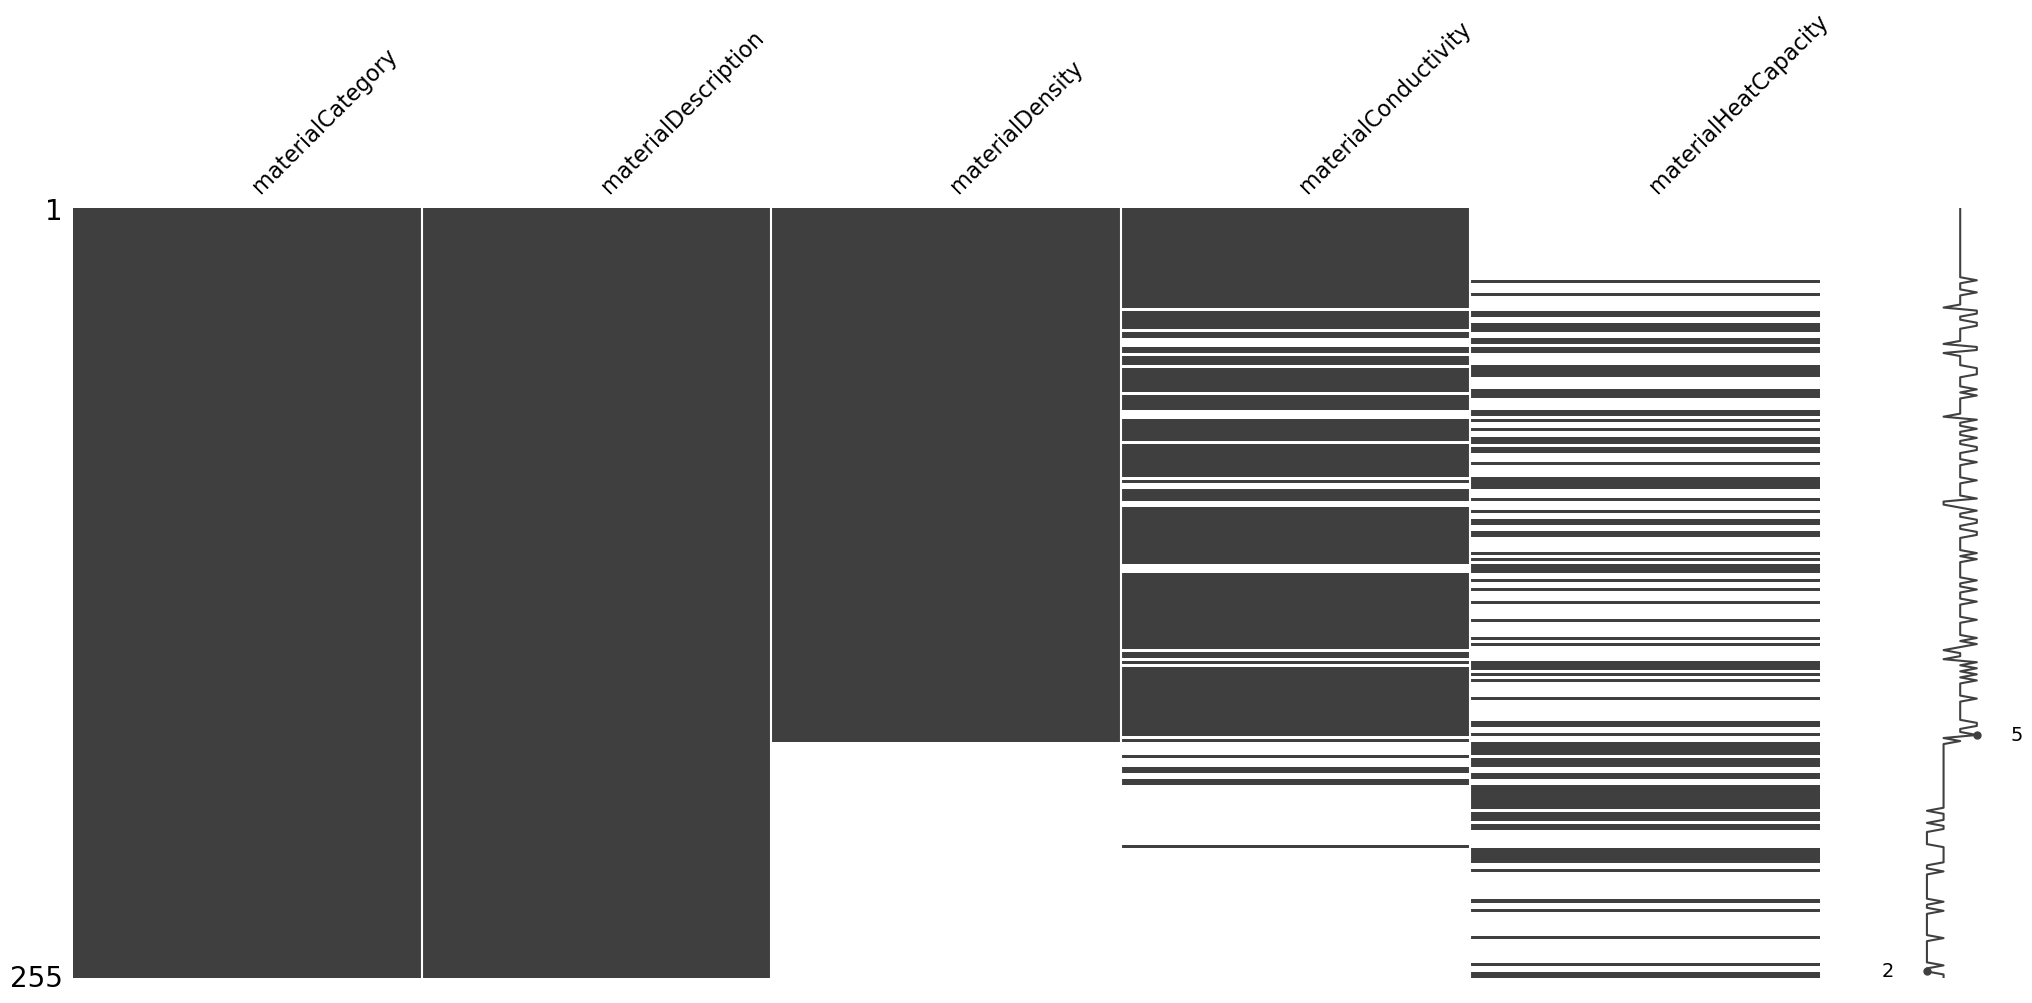

In [326]:
#We can see a strong correlation between material Density and materialConductivity from the plot. 
#We can confirm this by sorting either of the columns:
msno.matrix(materialData.sort_values("materialDensity"));

#The plot shows that if a data point is missing in materialDensity, 
#we can guess that it is somewhat related and also missing from materialConductivity and materialHeatCapacity
#there is weak correlation between density and capacity
#columns are not missing at random (MNAR)

## Impute Mean, Median, Mode

In [329]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [330]:
mean_imputation = materialData.copy()
median_imputation = materialData.copy()
mode_imputation = materialData.copy()

# Impute specific columns
mean_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']] = mean_imputation[
    ['materialDensity', 'materialConductivity', 'materialHeatCapacity']
].fillna(mean_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']].mean())

median_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']] = \
    median_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']].fillna(
        median_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']].median()
    )

mode_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']] = \
    mode_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']].fillna(
        mode_imputation[['materialDensity', 'materialConductivity', 'materialHeatCapacity']].mode().iloc[0]
    )


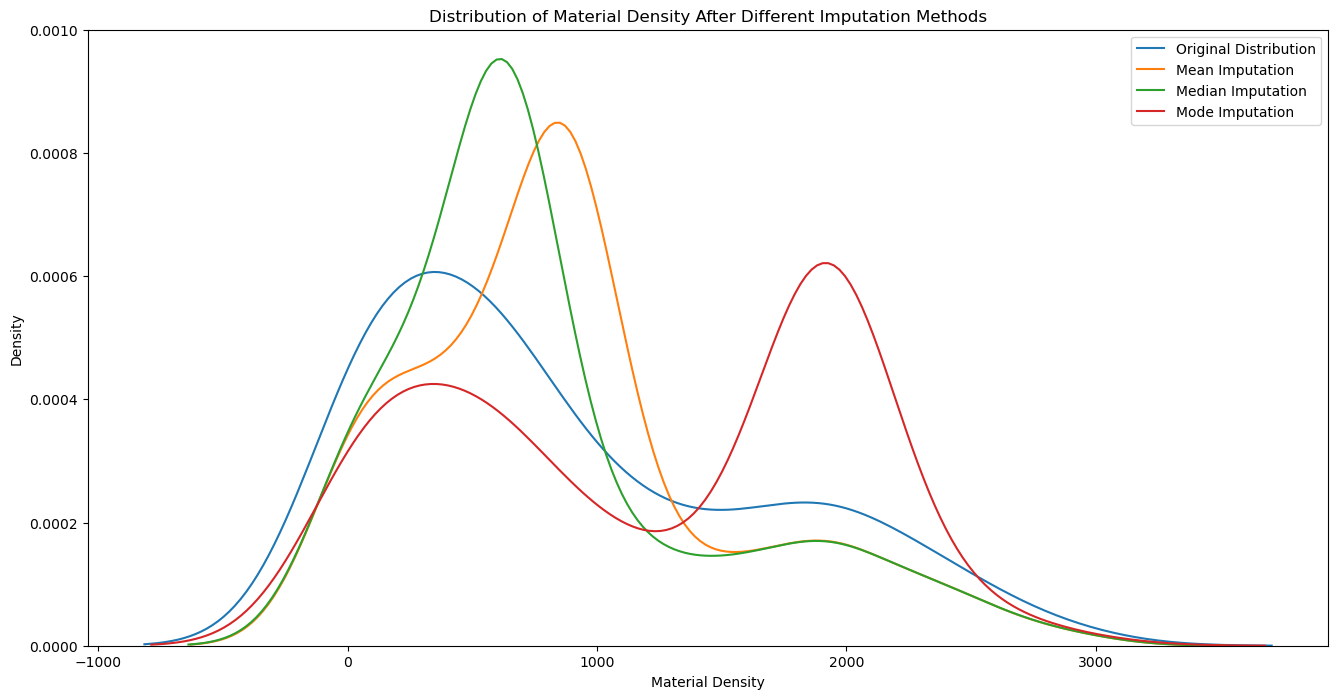

In [331]:
# Plotting the distributions for 'materialDensity'
fig, ax = plt.subplots(figsize=(16, 8))

# Original
sns.kdeplot(materialData['materialDensity'].dropna(), label="Original Distribution", ax=ax)

# Mean # Median # Mode
sns.kdeplot(mean_imputation['materialDensity'], label="Mean Imputation", ax=ax)
sns.kdeplot(median_imputation['materialDensity'], label="Median Imputation", ax=ax)
sns.kdeplot(mode_imputation['materialDensity'], label="Mode Imputation", ax=ax)

plt.legend()
plt.title('Distribution of Material Density After Different Imputation Methods')
plt.xlabel('Material Density')
plt.ylabel('Density')
plt.show()


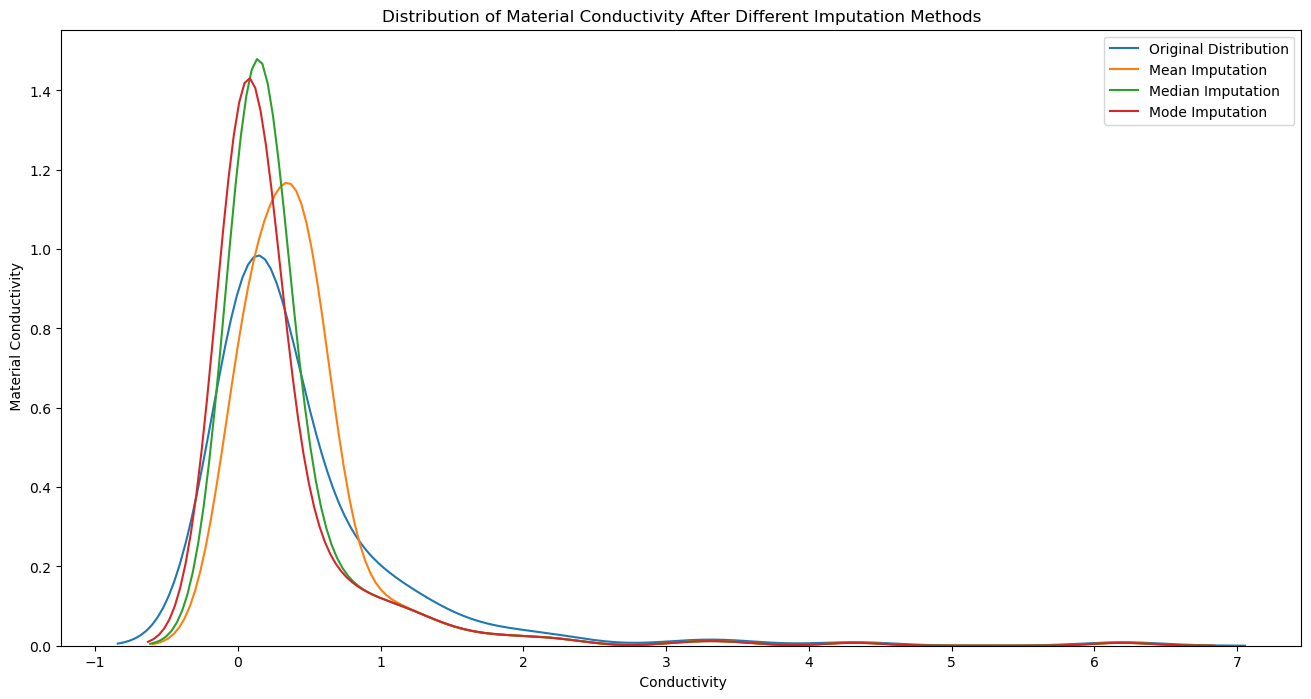

In [332]:
# Plotting the distributions for 'materialDensity'
fig, ax = plt.subplots(figsize=(16, 8))

# Original
sns.kdeplot(materialData['materialConductivity'].dropna(), label="Original Distribution", ax=ax)

# Mean # Median # Mode
sns.kdeplot(mean_imputation['materialConductivity'], label="Mean Imputation", ax=ax)
sns.kdeplot(median_imputation['materialConductivity'], label="Median Imputation", ax=ax)
sns.kdeplot(mode_imputation['materialConductivity'], label="Mode Imputation", ax=ax)

plt.legend()
plt.title('Distribution of Material Conductivity After Different Imputation Methods')
plt.xlabel(' Conductivity')
plt.ylabel(' Material Conductivity')
plt.show()


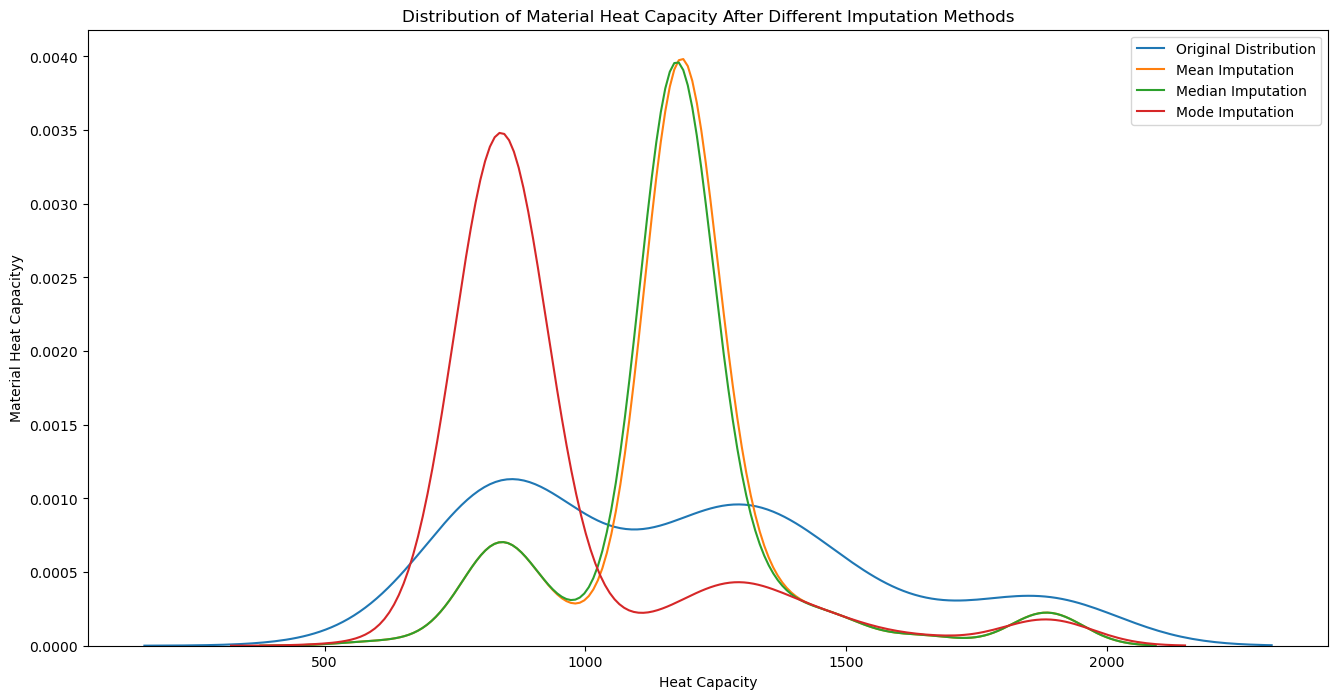

In [333]:
# Plotting the distributions for 'materialDensity'
fig, ax = plt.subplots(figsize=(16, 8))

# Original
sns.kdeplot(materialData['materialHeatCapacity'].dropna(), label="Original Distribution", ax=ax)
 
# Mean # Median # Mode
sns.kdeplot(mean_imputation['materialHeatCapacity'], label="Mean Imputation", ax=ax)
sns.kdeplot(median_imputation['materialHeatCapacity'], label="Median Imputation", ax=ax)
sns.kdeplot(mode_imputation['materialHeatCapacity'], label="Mode Imputation", ax=ax)

plt.legend()
plt.title('Distribution of Material Heat Capacity After Different Imputation Methods')
plt.xlabel('Heat Capacity')
plt.ylabel('Material Heat Capacityy')
plt.show()


## Impute with KNN Imputer

#Sklearn uses K-Nearest-Neighbors (KNN) algorithm 
#KNN classification works depending on the value of k, the algorithm classifies new samples by the majority vote of the nearest k neighbors in classification. 
#KNN regressior, predicts the actual numerical value of a new sample, the algorithm takes the mean of the nearest k neighbors.”

#KNN Imputer is slightly modified version of the KNN algorithm. It tried to predict the value of numeric nullity by averaging the distances between its k nearest neighbors. 

In [336]:
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [337]:
!pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [338]:
#Copy the data
materialData_knn_impute = materialData.copy(deep=True)

#Init the transformer 
knn_imp = KNNImputer(n_neighbors=3)

#Fit/transform
target_cols = ['materialDensity', 'materialConductivity', 'materialHeatCapacity']
materialData_knn_impute[target_cols] = knn_imp.fit_transform(materialData_knn_impute[target_cols])

In [339]:
materialData_knn_impute.isnull().sum()

materialCategory        0
materialDescription     0
materialDensity         0
materialConductivity    0
materialHeatCapacity    0
dtype: int64

It is difficult to find the correct value for K. so we take visual inspections

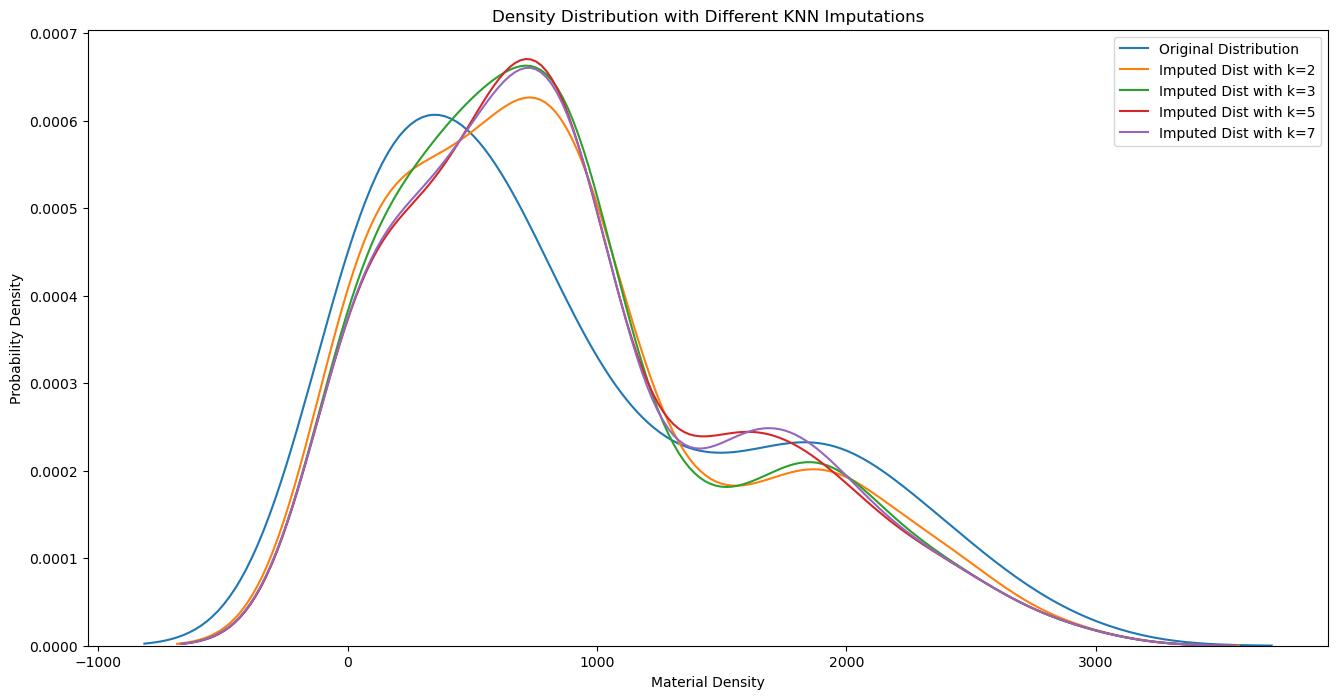

In [341]:
# Define the target columns for imputation
target_cols = ['materialDensity', 'materialConductivity', 'materialHeatCapacity']

n_neighbors = [2, 3, 5, 7]
fig, ax = plt.subplots(figsize=(16, 8))

# Original distribution of materialDensity
sns.kdeplot(materialData.materialDensity.dropna(), label="Original Distribution", ax=ax)

for k in n_neighbors:
    # Create a deep copy of the original data for imputation
    materialData_knn_impute = materialData.copy(deep=True)
    # Initialize the KNN Imputer
    knn_imp = KNNImputer(n_neighbors=k)
    # Apply KNN imputation only to the target columns
    materialData_knn_impute[target_cols] = knn_imp.fit_transform(materialData_knn_impute[target_cols])
    # Plot the imputed 'materialDensity' distribution
    sns.kdeplot(materialData_knn_impute.materialDensity, label=f"Imputed Dist with k={k}", ax=ax)

# Add legend and titles
plt.legend()
plt.title("Density Distribution with Different KNN Imputations")
plt.xlabel("Material Density")
plt.ylabel("Probability Density")
plt.show()

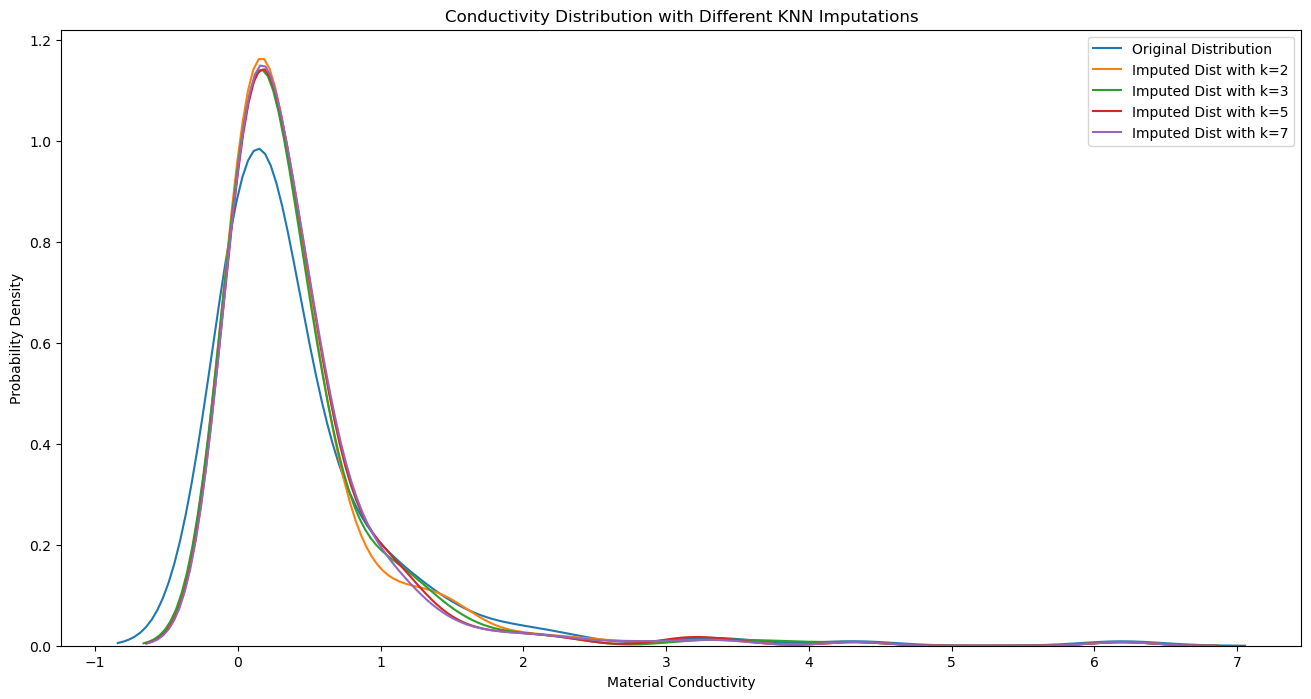

In [342]:
# Define the target columns for imputation
target_cols = ['materialDensity', 'materialConductivity', 'materialHeatCapacity']

n_neighbors = [2, 3, 5, 7]
fig, ax = plt.subplots(figsize=(16, 8))

# Plot original distribution of materialConductivity
sns.kdeplot(materialData.materialConductivity.dropna(), label="Original Distribution", ax=ax)

for k in n_neighbors:
    # Create a deep copy of the original data for imputation
    materialData_knn_impute = materialData.copy(deep=True)
    # Initialize the KNN Imputer
    knn_imp = KNNImputer(n_neighbors=k)
    # Apply KNN imputation only to the target columns
    materialData_knn_impute[target_cols] = knn_imp.fit_transform(materialData_knn_impute[target_cols])
    # Plot the imputed 'materialConductivity' distribution
    sns.kdeplot(materialData_knn_impute.materialConductivity, label=f"Imputed Dist with k={k}", ax=ax)

# Add legend and titles
plt.legend()
plt.title("Conductivity Distribution with Different KNN Imputations")
plt.xlabel("Material Conductivity")
plt.ylabel("Probability Density")
plt.show()

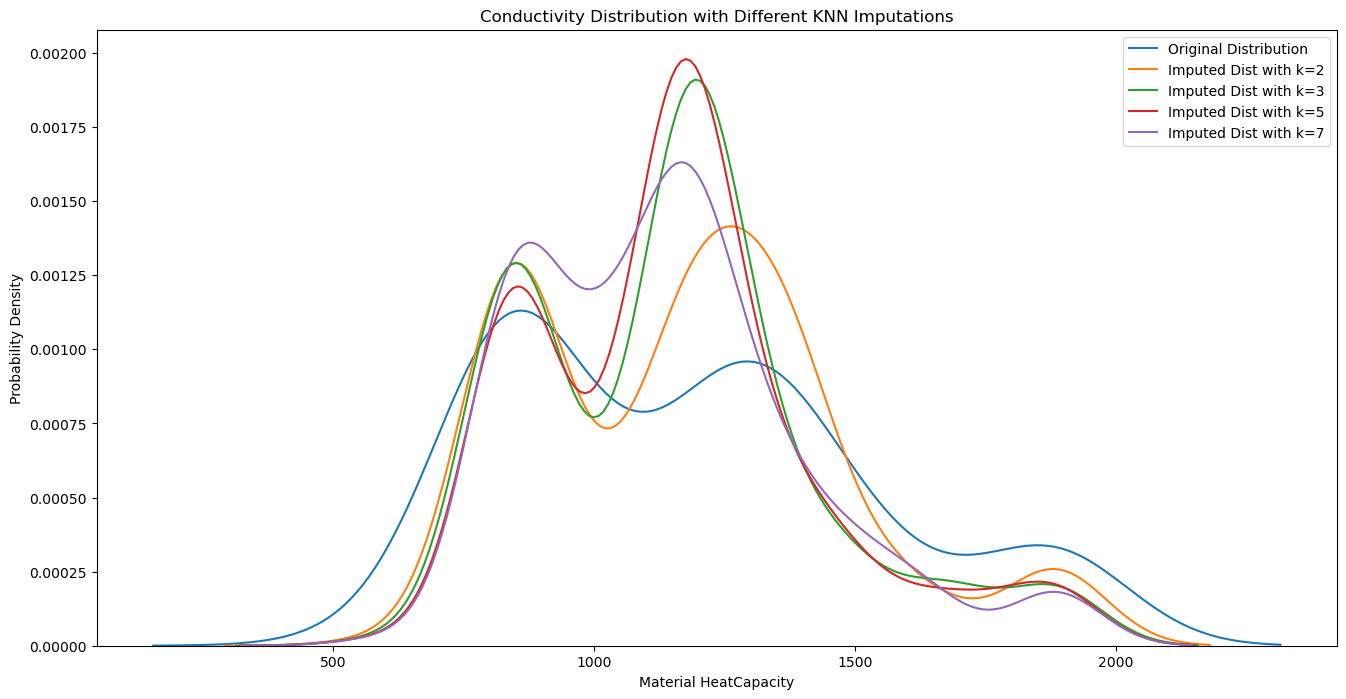

In [343]:
# Define the target columns for imputation
target_cols = ['materialDensity', 'materialConductivity', 'materialHeatCapacity']

n_neighbors = [2, 3, 5, 7]
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the original distribution of materialConductivity
sns.kdeplot(materialData.materialHeatCapacity.dropna(), label="Original Distribution", ax=ax)

for k in n_neighbors:
    # Create a deep copy of the original data for imputation
    materialData_knn_impute = materialData.copy(deep=True)
    # Initialize the KNN Imputer
    knn_imp = KNNImputer(n_neighbors=k)
    # Apply KNN imputation only to the target columns
    materialData_knn_impute[target_cols] = knn_imp.fit_transform(materialData_knn_impute[target_cols])
    # Plot the imputed 'materialConductivity' distribution
    sns.kdeplot(materialData_knn_impute.materialHeatCapacity, label=f"Imputed Dist with k={k}", ax=ax)

# Add legend and titles
plt.legend()
plt.title("Conductivity Distribution with Different KNN Imputations")
plt.xlabel("Material HeatCapacity")
plt.ylabel("Probability Density")
plt.show()

## Imputing With Iterative Imputer


1. A regressor is passed to the transformer.
2. The first feature (feature_1) with missing values is chosen.
3. The data is split into train/test sets where the train set contains all the known values for feature_1, and the test set contains the missing samples.
4. The regressor is fit on all the other variables as inputs and with feature_1 as an output.
5. The regressor predicts the missing values.
6. The transformer continues this process until all features are imputed.
7. Steps 1–6 are called a single iteration round, and these steps are carried out multiple times as specified by the max_iter transformer parameter.

In [346]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [347]:
#Copy the data
materialData_ii_imputed = materialData.copy(deep=True)

In [348]:
# Init, It models each feature with missing values as a function of other features in a round-robin fashion.
## ExtraTreesRegressor is used as the estimator. It is a machine learning model from the ensemble of decision trees.
## max_iter = 10 runs on max 10 iterations
## random_state=1121218: This sets the random seed for reproducibility. Initializing the random number generator in a way that ensures that the sequence of random numbers (or stochastic operations) generated will be the same each time the code is run. 

ii_imp = IterativeImputer(
    estimator=ExtraTreesRegressor(), max_iter=50, random_state=1121218
)

In [349]:
# Tranform
## [:, :]: This syntax selects all rows and all columns of the DataFrame.

# Define the target columns for imputation
target_cols = ['materialDensity', 'materialConductivity', 'materialHeatCapacity']

# Fit and transform the data, then assign the result back to the specified target columns
materialData_ii_imputed[target_cols] = ii_imp.fit_transform(materialData_ii_imputed[target_cols])

# Alternatively, if you want to impute all columns, you can use:
# materialData_ii_imputed.iloc[:, :] = ii_imp.fit_transform(materialData_ii_imputed)

# Now the data is imputed and stored in materialData_ii_imputed


C:\Users\20180031\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [352]:
materialData_ii_imputed.isnull().sum()

materialCategory        0
materialDescription     0
materialDensity         0
materialConductivity    0
materialHeatCapacity    0
dtype: int64

In [354]:
materialData_ii_imputed.describe()

,materialDensity,materialConductivity,materialHeatCapacity
count,255.000000,255.000000,255.000000
mean,801.659548,0.378824,1161.537356
std,687.356689,0.697258,283.693667
min,7.208309,0.021600,586.152000
25%,368.424658,0.087696,880.902720
50%,532.854185,0.138586,1176.909480
75%,1121.292438,0.300960,1297.908000
max,2883.323412,6.192000,1884.060000


In [357]:
print(materialData_ii_imputed)
#materialData_ii_imputed.to_excel("materialData_ii_imputed.xlsx", index=False)


                               materialCategory       materialDescription  \
0    Insulating material: Blanket and batt c, d         Glass-fiber batts   
1    Insulating material: Blanket and batt c, d         Glass-fiber batts   
2    Insulating material: Blanket and batt c, d         Glass-fiber batts   
3    Insulating material: Blanket and batt c, d         Glass-fiber batts   
4    Insulating material: Blanket and batt c, d         Glass-fiber batts   
..                                          ...                       ...   
250   Woods (12% moisture content) l: Hardwoods  West coast woods, cedars   
251   Woods (12% moisture content) l: Hardwoods      Eastern white cedar.   
252   Woods (12% moisture content) l: Hardwoods        California redwood   
253   Woods (12% moisture content) l: Hardwoods         Pine (oven-dried)   
254   Woods (12% moisture content) l: Hardwoods       Spruce (oven-dried)   

     materialDensity  materialConductivity  materialHeatCapacity  
0       

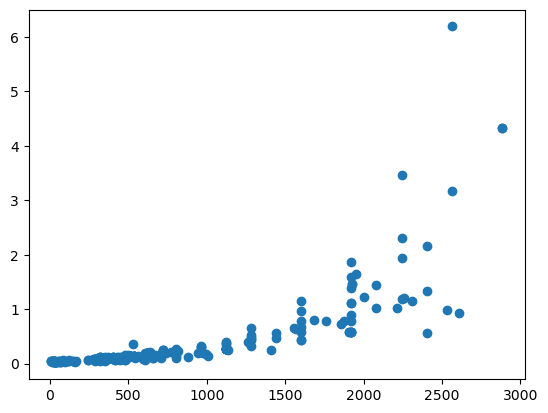

In [361]:
plt.scatter(materialData_ii_imputed.materialDensity, materialData_ii_imputed.materialConductivity)

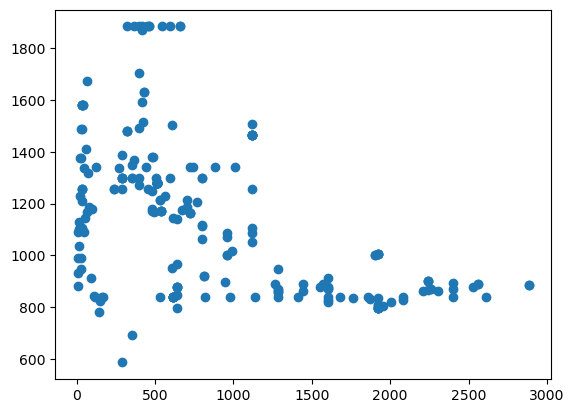

In [363]:
plt.scatter(materialData_ii_imputed.materialDensity, materialData_ii_imputed.materialHeatCapacity)

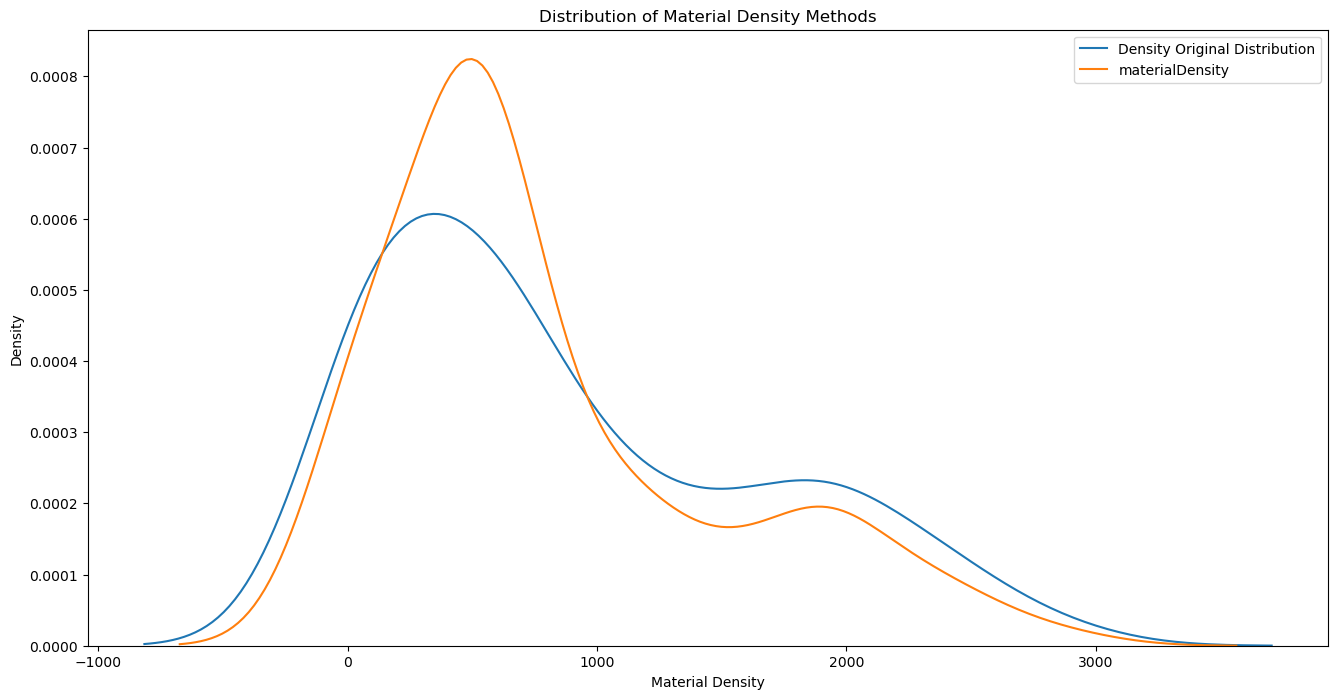

In [366]:
# Plotting---Denisty
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the original distribution
sns.kdeplot(materialData['materialDensity'].dropna(), label="Density Original Distribution", ax=ax)
# Plot iterative imputation density
sns.kdeplot(materialData_ii_imputed.materialDensity, label="materialDensity", ax=ax)

# Add legend
plt.legend()

# Add titles and labels
plt.title('Distribution of Material Density Methods')
plt.xlabel('Material Density')
plt.ylabel('Density')

# Show the plot
plt.show()

In [367]:
materialData['materialDensity'].describe()

count     177.000000
mean      880.752133
std       772.080539
min         7.208309
25%       288.332341
50%       640.738536
75%      1441.661706
max      2883.323412
Name: materialDensity, dtype: float64

In [368]:
materialData_ii_imputed.materialDensity.describe()

count     255.000000
mean      801.659548
std       687.356689
min         7.208309
25%       368.424658
50%       532.854185
75%      1121.292438
max      2883.323412
Name: materialDensity, dtype: float64

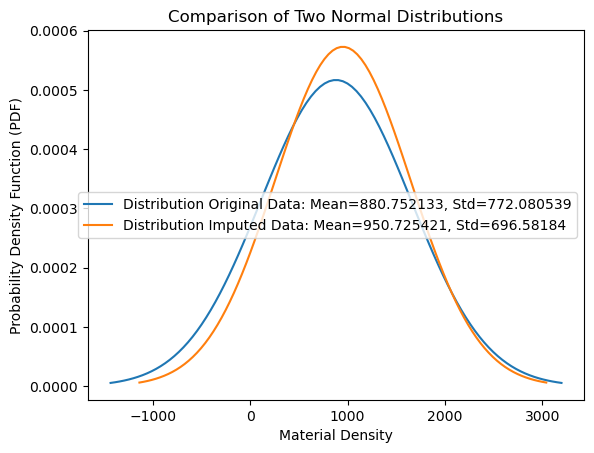

In [369]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Provided summary statistics for the first distribution
mean1 = 880.752133
std1 = 772.080539

# Provided summary statistics for the second distribution
#mean2 = 779.434558
mean2 = 950.725421

#std2 = 689.819031
std2 =  696.581840
# Generate x-values for the range covering both distributions
x1 = np.linspace(mean1 - 3*std1, mean1 + 3*std1, 100)
x2 = np.linspace(mean2 - 3*std2, mean2 + 3*std2, 100)

# Calculate the PDF for both distributions
pdf1 = stats.norm.pdf(x1, mean1, std1)
pdf2 = stats.norm.pdf(x2, mean2, std2)

# Plot both distributions
plt.plot(x1, pdf1, label=f'Distribution Original Data: Mean={mean1}, Std={std1}')
plt.plot(x2, pdf2, label=f'Distribution Imputed Data: Mean={mean2}, Std={std2}')

# Adding titles and labels
plt.title('Comparison of Two Normal Distributions')
plt.xlabel('Material Density')
plt.ylabel('Probability Density Function (PDF)')
plt.legend()

# Display the plot
plt.show()

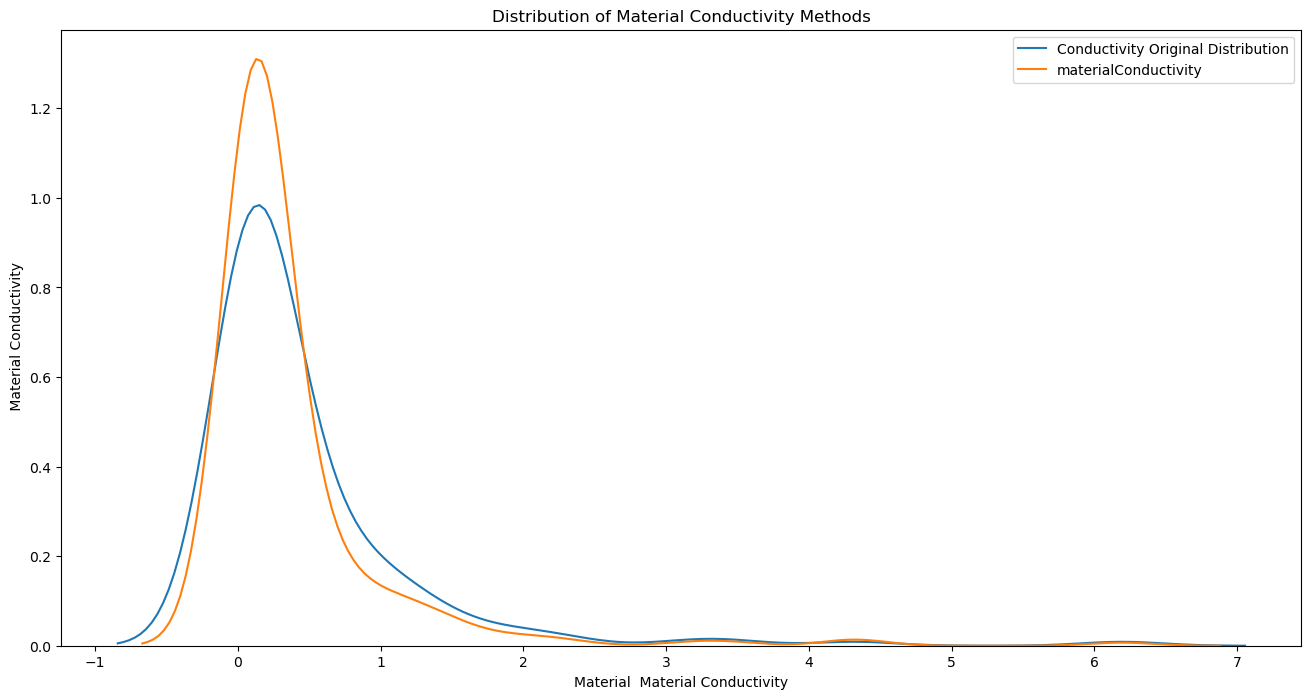

In [370]:
# Plotting---Conductivity
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the original distribution
sns.kdeplot(materialData['materialConductivity'].dropna(), label="Conductivity Original Distribution", ax=ax)
# Plot mean imputation
sns.kdeplot(materialData_ii_imputed.materialConductivity, label="materialConductivity", ax=ax)

# Add legend
plt.legend()

# Add titles and labels
plt.title('Distribution of Material Conductivity Methods')
plt.xlabel('Material  Material Conductivity')
plt.ylabel(' Material Conductivity')

# Show the plot
plt.show()



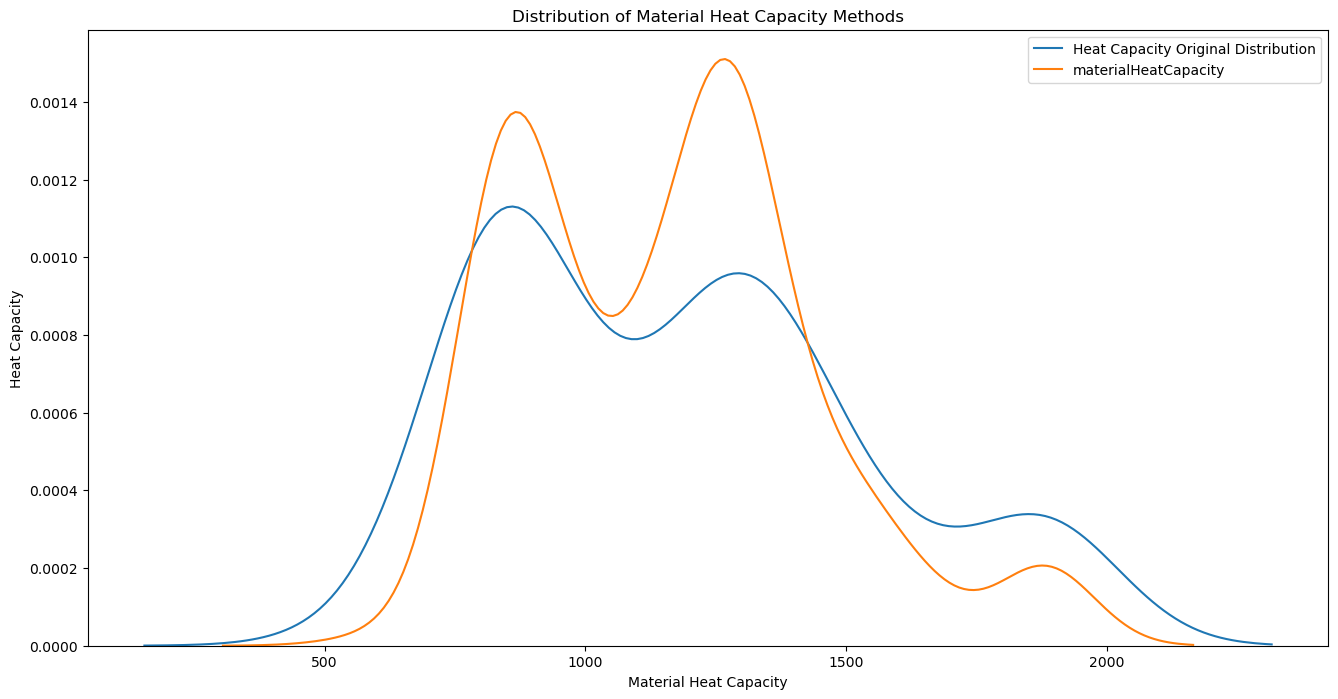

In [371]:
# Plotting---Heat Capacity
fig, ax = plt.subplots(figsize=(16, 8))

# Plot the original distribution
sns.kdeplot(materialData['materialHeatCapacity'].dropna(), label="Heat Capacity Original Distribution", ax=ax)
# Plot mean imputation
sns.kdeplot(materialData_ii_imputed.materialHeatCapacity, label="materialHeatCapacity", ax=ax)


# Add legend
plt.legend()

# Add titles and labels
plt.title('Distribution of Material Heat Capacity Methods')
plt.xlabel('Material Heat Capacity')
plt.ylabel('Heat Capacity')

# Show the plot
plt.show()



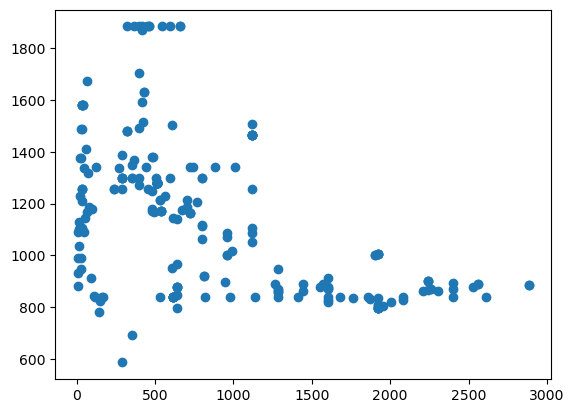

In [372]:
plt.scatter(materialData_ii_imputed.materialDensity, materialData_ii_imputed.materialHeatCapacity)

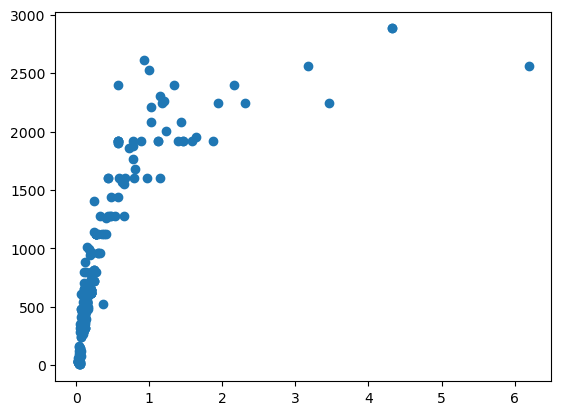

In [373]:
plt.scatter(materialData_ii_imputed.materialConductivity, materialData_ii_imputed.materialDensity)

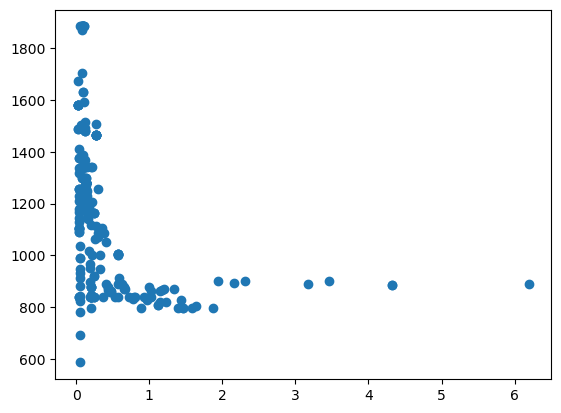

In [374]:
plt.scatter(materialData_ii_imputed.materialConductivity, materialData_ii_imputed.materialHeatCapacity)

## Correlation matrix

In [385]:
from scipy import stats
import seaborn as sns

In [386]:
# Calculate the correlation matrix for the relevant columns
correlation_matrix = materialData_ii_imputed[['materialDensity', 'materialConductivity', 'materialHeatCapacity']].corr()

# Print the correlation matrix
print(correlation_matrix)


                      materialDensity  materialConductivity  \
materialDensity              1.000000              0.753842   
materialConductivity         0.753842              1.000000   
materialHeatCapacity        -0.508237             -0.391072   

                      materialHeatCapacity  
materialDensity                  -0.508237  
materialConductivity             -0.391072  
materialHeatCapacity              1.000000  


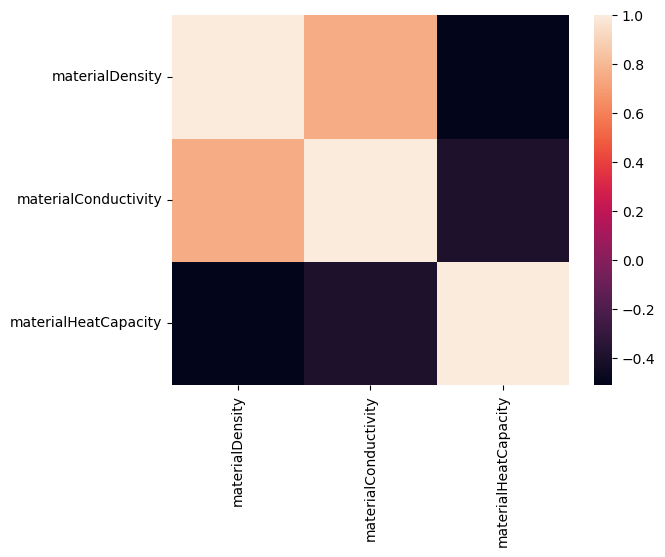

In [387]:
sns.heatmap(correlation_matrix);

## Regression Interporlation

IterativeImputer by Sklearn: https://scikit-learn.org/stable/auto_examples/impute/plot_iterative_imputer_variants_comparison.html
BayesianRidge and ExtraTreeRegressor yield the best results.

Predict materialDensity based on materialConductivity and materialHeatCapacity, 
suit regression involve imputing missing values in dataset, training regression models, and evaluating their performance using cross-validation.

1. Prepare Your Data:
Separate your features (materialConductivity and materialHeatCapacity) and the target (materialDensity).
2. Set Up Imputation and Regression:
Use imputation methods like IterativeImputer and KNNImputer.
Use regression models like BayesianRidge and ExtraTreesRegressor.
3. Evaluate with Cross-Validation:
Use cross-validation to evaluate the performance of the models.

In [408]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder

### Define df and encode to label, to make binary use onehotencoder.
drop material densityt of X_full, reshape Y_full to 1 dimensional array
cross validation: coefficient of variantion:

In [431]:
# Drop rows where 'materialDensity', 'materialCategory', or 'materialDescription' have missing values
materialData = materialData.dropna(subset=['materialDensity', 'materialCategory', 'materialDescription'])

# Encode categorical features
label_encoder_category = LabelEncoder()
materialData['materialCategory'] = label_encoder_category.fit_transform(materialData['materialCategory'])

label_encoder_description = LabelEncoder()
materialData['materialDescription'] = label_encoder_description.fit_transform(materialData['materialDescription'])

# Feature/target arrays
X_full = materialData.drop("materialDensity", axis=1).copy()  # All features except 'materialDensity'
y_full = materialData["materialDensity"].values.reshape(-1, 1)  # changing the shape of an array.

# Set global configurations cross validation: prevent from overfitting, difficult to do with little data, yet relevant to 
cv = 5  # Coefficient of variation (you can adjust this as needed)
scoring = "neg_mean_squared_error"  # Use MSE for regression
state = 1121218  # Random seed for reproducibility


In [433]:
# Store IterativeImputer scores
ii_scores = pd.DataFrame()

# Iterate over both estimators (BayesianRidge and ExtraTreesRegressor)
for estimator in [BayesianRidge(), ExtraTreesRegressor()]:
    # Create a pipeline with IterativeImputer and the current estimator
    pipe = make_pipeline(
        IterativeImputer(estimator=estimator, random_state=state, max_iter=10), estimator
    )
    
    # Evaluate the pipeline using cross-validation
    ii_scores[estimator.__class__.__name__] = cross_val_score(
        pipe, X_full, y_full.ravel(), scoring=scoring, cv=cv
    )

# Print the cross-validation scores for each estimator
print(ii_scores) #follow the negative MSE (the lower the better)

C:\Users\20180031\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\20180031\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\20180031\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\20180031\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


   BayesianRidge  ExtraTreesRegressor
0  -1.175444e+06        -22719.872512
1  -3.103585e+05       -271075.593719
2  -4.522884e+05       -216269.938760
3  -1.508920e+06       -313146.256759
4  -3.642344e+05        -39923.433078


C:\Users\20180031\AppData\Local\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


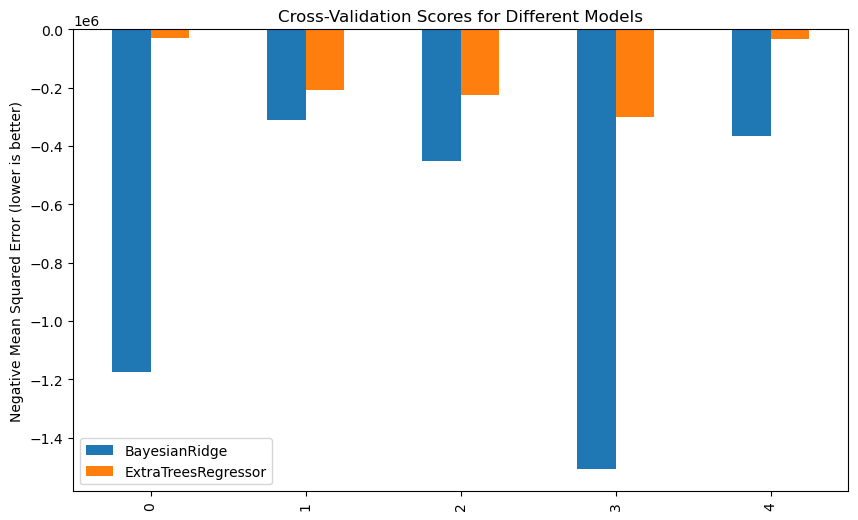

In [412]:
import matplotlib.pyplot as plt

# Plot the cross-validation scores
ii_scores.plot(kind="bar", figsize=(10, 6))
plt.ylabel('Negative Mean Squared Error (lower is better)')
plt.title('Cross-Validation Scores for Different Models')
plt.show()

## Pipeline: KNN + Extra Tree and Bayesian 

1) create new pd df
2) define k neighbors, fill in missing values in the features (X_full in this case all feature excpet Y(density) ) by averaging the values of the k nearest neighbors.

In [416]:
# Make pipeline: Store KNN scores using extra tree regressor
knn_scores_extraTree = pd.DataFrame()
n_neighbors = [2, 3, 5, 7, 9]
for k in n_neighbors:
    pipe = make_pipeline(KNNImputer(n_neighbors=k), ExtraTreesRegressor())
    knn_scores[f"KNN(k = {k})"] = cross_val_score(
        pipe, X_full, y_full.ravel(), scoring=scoring, cv=cv
    )

In [418]:
# Make a pipeline: Store KNN scores using bayesian ridge as regresion method.
knn_scores_Bayseian = pd.DataFrame()
n_neighbors = [2, 3, 5, 7, 9]
for k in n_neighbors:
    pipe = make_pipeline(KNNImputer(n_neighbors=k), BayesianRidge())
    knn_scores[f"KNN(k = {k})"] = cross_val_score(
        pipe, X_full, y_full.ravel(), scoring=scoring, cv=cv
    )

C:\Users\20180031\AppData\Local\Temp\ipykernel_8272\2044336716.py:2: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  final_scores = pd.concat(


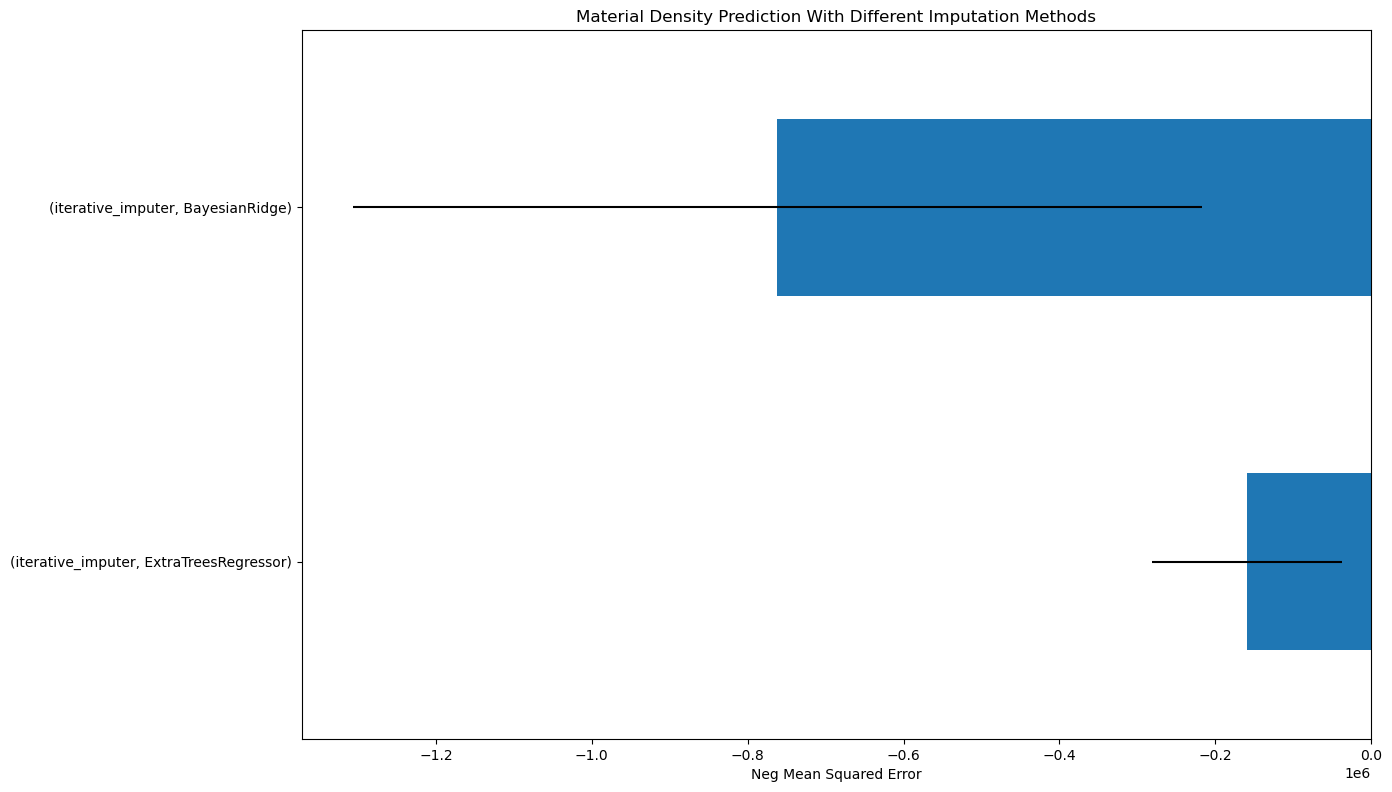

In [426]:
# Combine scores into a single DF
final_scores = pd.concat(
    [ii_scores, knn_scores_extraTree, knn_scores_Bayseian],
    axis=1,
    keys=["iterative_imputer", "knn_imputer"],
)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

means, errors = final_scores.mean().sort_values(ascending=False), final_scores.std()
means.plot.barh(xerr=errors, ax=ax)

ax.set_title("Material Density Prediction With Different Imputation Methods")
ax.set_xlabel("Neg Mean Squared Error")
ax.set_yticks(np.arange(means.shape[0]))

plt.tight_layout(pad=1)
plt.show()

Summary from Imputations

Summary from Imputations

Summary from Imputations

Summary from Imputations

Summary from Imputations

Summary from Imputations